# **Task 2 : The Multi-Tiered Detective**

---

Task 1 established that my stylometric features separate the classes. Now I want to know if a machine can actually use those features to classify. As instructed, I'm building three classifiers of increasing sophistication:

- **Tier A** — XGBoost on the 15 stylometric features from Task 1
- **Tier B** — Feedforward NN on averaged GloVe word embeddings (300-dimensional)
- **Tier C** — Fine-tuned DistilBERT with LoRA

I have some hypotheses for Task 2 based on my observations from Task 1. I will evaluate them after running the tiers.

- **H1:**  Tier A will easily separate Human class from Generic AI because `past_tense_ratio` and `semicolon_rate` have a good class separation (saw in Task 1). It will struggle with Human vs Mimic AI.

- **H2:**  Tier B will perform the worst because all classes cover the same 10 topics. Averaged GloVe embeddings will encode semantics while the classes differ in writing style, so they shouldn't distinguish the classes well.

- **H3:**  Tier C will perform best overall because a contextual transformer sees syntax, rhythm, and token distribution patterns.

- **H4:**  `past_tense_ratio` and `semicolon_rate` will be Tier A's top features by importance. Task 1 showed that these have the largest class separation.

- **H5:**  Mimic AI will be the most confused class because it is prompted to sit in the middle of Human and Generic AI.

### **Imports and Setup**

In [4]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

np.random.seed(42) # Using the same seed from Task 1
torch.manual_seed(42)

# Adding notebooks/ directory to the path for importing feature_extraction.py
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from feature_extraction import (
    load_jsonl, extract_all_features, FEATURE_COLUMNS
)

DATA_DIR = '../data'
MODELS_DIR = '../models'
FIGURES_DIR = '../figures/task2'

print('Setup complete.')

Setup complete.


### **Step 0: Computing val and test feature matrices**

I computed and saved the training feature matrix in Task 1. Val and test splits need the same features extracted with the same functions. For a cleaner look, I'm importing those functions from `feature_extraction.py` in the `notebooks` directoryrather than re-running Task 1.

In [ ]:
def build_feature_csv(split_name):
    path = os.path.join(DATA_DIR, 'splits', f'{split_name}.jsonl')
    out_path = os.path.join(DATA_DIR, 'features', f'{split_name}_features.csv')

    if os.path.exists(out_path):
        print(f'{split_name}_features.csv already exists. Loading it...')
        return pd.read_csv(out_path)

    records = load_jsonl(path)
    rows = [] 
    for i, rec in enumerate(tqdm(records, desc=split_name)):
        row = extract_all_features(rec['text'], rec['label'], i) # function imported from feature_extraction.py
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    print(f'Saved {out_path}  ({len(df)} rows)')
    return df

df_val  = build_feature_csv('val')
df_test = build_feature_csv('test')
df_train = pd.read_csv(os.path.join(DATA_DIR, 'features', 'train_features.csv'))

print(f'\nTrain: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}')
print('\nClass distribution in test split:')
print(df_test['label'].value_counts().sort_index())

val: 100%|██████████| 226/226 [00:11<00:00, 20.47it/s]


Saved ../data\features\val_features.csv  (226 rows)


test: 100%|██████████| 225/225 [00:10<00:00, 21.36it/s]

Saved ../data\features\test_features.csv  (225 rows)

Train: (1049, 17), Val: (226, 17), Test: (225, 17)

Class distribution in test split:
label
0    75
1    75
2    75
Name: count, dtype: int64


### **Tier A (The Statistician): XGBoost**

I am choosing XGBoost here because the feature importance output is more informative and I want some hands-on practice with it. Random Forest averages impurity across trees in a way that can mask redundant features. Also, XGBoost's gain-based importance is easier to interpret, and gain directly tells which features are contributing to splits in the decision tree that actually reduce error. [[1]](https://medium.com/@emilykmarsh/xgboost-feature-importance-233ee27c33a4) [[2]](https://xgboost.readthedocs.io/en/latest/r_docs/R-package/docs/reference/xgb.importance.html) [[3]](https://medium.com/@hisah075/gini-impurity-a-comprehensive-guide-for-decision-trees-3934a2f13d55)[[4]](https://stackoverflow.com/questions/57360703/feature-importance-gain-in-xgboost)

I'm going to tune three hyperparameters that matter most:
- `n_estimators`: More trees = lower variance (I am expecting diminishing returns)
- `max_depth`: This will control overfitting. shallow tree will work better on my small dataset.
- `learning_rate`: lower = slower but more stable convergence

I will use a 5-fold stratified cross-validation on the training set for selection, then a final eval on the held-out test set. [[5]](https://medium.com/@dicee/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d)

In [6]:
FEATURE_COLS = [c for c in FEATURE_COLUMNS if c not in ('label', 'text_id')]


X_train = df_train[FEATURE_COLS].values # 2D array (row = a sample and column = one of the extracted features)
y_train = df_train['label'].values # Class labels
X_val   = df_val[FEATURE_COLS].values
y_val   = df_val['label'].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test['label'].values

print(f'Feature set: {len(FEATURE_COLS)} features')
print(FEATURE_COLS)

Feature set: 15 features
['ttr', 'mattr', 'adj_noun_ratio', 'adv_per_100', 'past_tense_ratio', 'noun_density', 'tree_depth', 'comma_rate', 'semicolon_rate', 'colon_rate', 'emdash_rate', 'exclamation_rate', 'question_rate', 'fk_grade', 'reading_ease']


**Hyperparameter tuning using Grid Search**

Grid Search tries every combination of the given hyperparameters and evaluates the model's performance using cross-validation. Since XGBoost's performance is sensitive to the combination of `n_estimators`, `max_depth`, and `learning_rate`, Grid Search will try 27 combinations (3 values for each of the 3 hyperparameters) by brute-force. Whichever combination of hyperparameters comes out best is selected. [[6]](https://medium.com/@Mandeep2002/gridsearchcv-key-concepts-8f98ceb633e4
) [[7]](https://www.analyticsvidhya.com/blog/2021/06/tune-hyperparameters-with-gridsearchcv/)

The hyperparameter values that I will be trying are:
- `n_estimators`: [100, 200, 500] - 100 is reasonable and 500 is where the gains might plateau for a small dataset.
- `max_depth`: [3, 5, 7] - Depth-3 trees are shallow and high-bias (underfit risk), whereas depth-7 is deep and high-variance (overfitting risk). The number of decision boundaries that the data needs will determine the optimal depth.
- `learning_rate`: [0.01, 0.1, 0.3] - I am trying to cover the standard three orders of magnitude. A low learning rate with a few trees will probably underfit and a high learning rate with many trees may overfit. 
[[5]](https://medium.com/@dicee/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d)

In [ ]:
# Hyperparameter grid for GridSearchCV hyperparameter tuning
param_grid = {
    'n_estimators':  [100, 200, 500],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
}

# Initializing the XGBoost classifier for multi-class classification with softmax probabilities
# Setting the evaluation metric to multi-class log loss
base_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold stratified cross-validation

grid_search = GridSearchCV(
    base_clf, param_grid,
    cv=cv, scoring='f1_macro', # Using macro-F1 because the classes are imbalanced (the difficulty level is different)
    n_jobs=-1, verbose=1, # verbose=1 will print progress messages during the grid search
)
grid_search.fit(X_train, y_train)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV macro-F1: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits


d:\Precog-Recruitment-Task\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:06:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 500}
Best CV macro-F1: 0.9809


In [8]:
best_xgb = grid_search.best_estimator_

# Val performance
y_val_pred = best_xgb.predict(X_val)
print('--- Validation performance ---')
print(classification_report(y_val, y_val_pred,
      target_names=['Human', 'Generic AI', 'Mimic AI']))

# Final test evaluation
y_test_pred = best_xgb.predict(X_test)
print('--- Test performance ---')
print(classification_report(y_test, y_test_pred,
      target_names=['Human', 'Generic AI', 'Mimic AI']))
print(f'Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Test macro-F1: {f1_score(y_test, y_test_pred, average="macro"):.4f}')

--- Validation performance ---
              precision    recall  f1-score   support

       Human       0.99      0.96      0.97        75
  Generic AI       0.97      0.96      0.97        75
    Mimic AI       0.96      1.00      0.98        76

    accuracy                           0.97       226
   macro avg       0.97      0.97      0.97       226
weighted avg       0.97      0.97      0.97       226

--- Test performance ---
              precision    recall  f1-score   support

       Human       0.97      0.99      0.98        75
  Generic AI       0.99      0.96      0.97        75
    Mimic AI       0.99      1.00      0.99        75

    accuracy                           0.98       225
   macro avg       0.98      0.98      0.98       225
weighted avg       0.98      0.98      0.98       225

Test accuracy: 0.9822
Test macro-F1: 0.9822


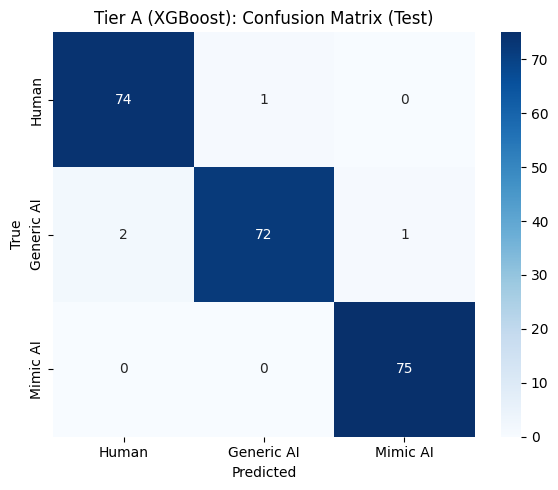

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Human', 'Generic AI', 'Mimic AI'],
            yticklabels=['Human', 'Generic AI', 'Mimic AI'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Tier A (XGBoost): Confusion Matrix (Test)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tier_a_confusion.png'), dpi=150)
plt.show()

**Interpreting the Confusion Matrix**

- Human Class is mostly correctly classified, with a misclassification as Generic AI. It is interesting that zero Human paragraphs were misclassified as Mimic AI, and zero Mimic AI paragraphs were misclassified as Human. The decision boundary between them is clean.

- Generic AI Class has the most errors of any class: 2 samples called Human and 1 called Mimic AI. My hypothesis that Mimic AI would be the hardest class was wrong.

- Mimic AI Class is perfectly classified. Quite surprisingly.

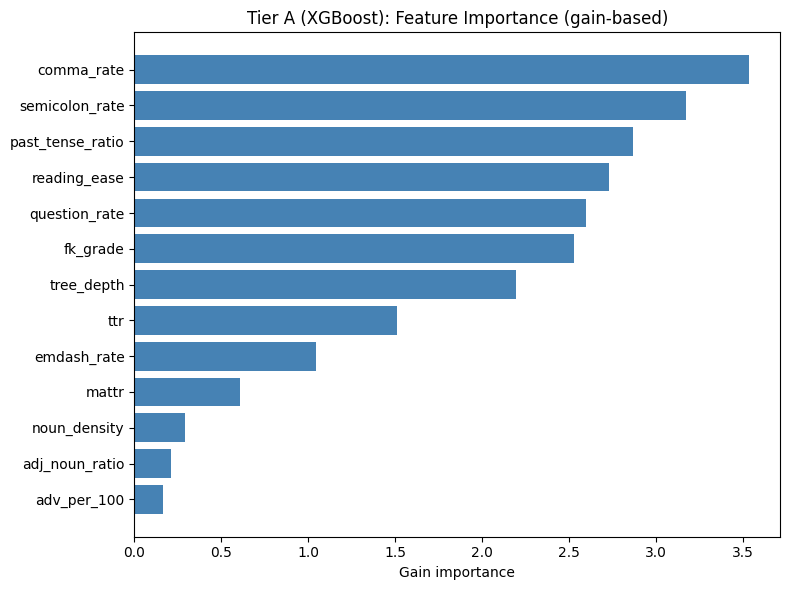


Top 5 features by gain:
         feature  importance
   question_rate    2.594105
    reading_ease    2.728344
past_tense_ratio    2.867660
  semicolon_rate    3.173704
      comma_rate    3.535313


In [13]:
# Feature importance (gain-based)
importances = best_xgb.get_booster().get_score(importance_type='gain')
# Mapping internal feature names (f0, f1, ...) back to readable names
imp_df = pd.DataFrame([
    {'feature': FEATURE_COLS[int(k[1:])], 'importance': v}
    for k, v in importances.items()
]).sort_values('importance', ascending=True) 

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_xlabel('Gain importance')
ax.set_title('Tier A (XGBoost): Feature Importance (gain-based)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tier_a_feature_importance.png'), dpi=150)
plt.show()

print('\nTop 5 features by gain:')
print(imp_df.tail(5).to_string(index=False)) 

In [ ]:
# I am running XGBoost a second time but this time, I am dropping weak features. In task 1, I saw that
# tree_depth feature has inverted correlation and SpaCy misparse of Victorian proses. 
# Also, adv_per_100 showed heavy class overlap. I want to see if dropping them helps or hurts.

FEATURE_COLS_REDUCED = [f for f in FEATURE_COLS if f not in ('tree_depth', 'adv_per_100')]

X_tr_r  = df_train[FEATURE_COLS_REDUCED].values
X_val_r = df_val[FEATURE_COLS_REDUCED].values
X_te_r  = df_test[FEATURE_COLS_REDUCED].values

clf_reduced = xgb.XGBClassifier(
    **grid_search.best_params_,
    objective='multi:softprob',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)
clf_reduced.fit(X_tr_r, y_train)

y_te_r_pred = clf_reduced.predict(X_te_r)
print('--- Reduced feature set Test ---')
print(classification_report(y_test, y_te_r_pred,
      target_names=['Human', 'Generic AI', 'Mimic AI']))
print(f'Accuracy: {accuracy_score(y_test, y_te_r_pred):.4f}')
print(f'Macro-F1: {f1_score(y_test, y_te_r_pred, average="macro"):.4f}')

d:\Precog-Recruitment-Task\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:44:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Reduced feature set Test ---
              precision    recall  f1-score   support

       Human       0.97      0.97      0.97        75
  Generic AI       0.97      0.97      0.97        75
    Mimic AI       1.00      1.00      1.00        75

    accuracy                           0.98       225
   macro avg       0.98      0.98      0.98       225
weighted avg       0.98      0.98      0.98       225

Accuracy: 0.9822
Macro-F1: 0.9822


### **Results and interpretation of Tier A**

98.22% test accuracy, 0.98 macro-F1. This is too good to be true for a 3-class NLP problem where I did Feature Engineering myself. If I consider these results accurate, the stylometric signal is strong enough that a simple XGBoost already solved the task.

- My hypothesis, **H1, got rejected**. I predicted that Tier A would struggle with Human vs Mimic AI but the confusion matrix shows zero errors in both directions. I think `past_tense_ratio` (Human=0.58, Mimic AI=0.09) made this an almost trivial split. Even though my Mimic AI prompt was to write in Shelley's style, but Gemini used present tense anyways.

- **H4 is partially confirmed.** `semicolon_rate` and `past_tense_ratio` are both in the top 3 features by importance, which matches my prediction. But `comma_rate` is the most important instead of `past_tense_ratio`. After a long conversation with [DeepSeek's reasoning LLM](https://chat.deepseek.com), I guess that `past_tense_ratio` creates a 2-way split (Human > both AI classes), but `comma_rate` creates a 3-way split: Mimic AI (85.90) > Human (75.40) > Generic AI (48.85). It is possible that features that separate all three classes simultaneously get higher gain than one that only helps with one boundary. [[8]](https://chat.deepseek.com)

- **H5 rejected.** Mimic AI was the easiest class (100% recall on both val and test). Generic AI was the most confused because it had 3 total errors out of which 2 were misclassified as Human.

- I dropped `tree_depth` and `adv_per_100`. The model still achieved the same overall accuracy (0.9822) but improved Mimic AI F1 from 0.99 to 1.00. I guess these two features were adding a small amount of noise to the Mimic AI class. For `tree_depth`, I discussed in Task 1 that SpaCy maybe misparsed some Victorian paragraphs because it was trained on modern English.

- While tuning the hyperparameters, the best config came out to be: `max_depth=3, n_estimators=500, learning_rate=0.3`. Shallow trees (depth=3) means the actual decision boundary was simple. This makes sense because a single feature (`past_tense_ratio`) nearly solved the Human vs AI boundary alone. Many trees with high learning rate provided ensemble stability without overfitting, probably because each tree is too shallow to memorize the training samples.

### **References for Tier A**

**AI and Tool Usage**

[DeepSeek's Reasoning LLM](https://www.deepseek.com/en/) (cited in-line) helped me interpret the feature importance output and understand how `comma_rate` created a 3-way split. I structured hyperparameter tuning using GridSearchCV based on the concepts explained in my cited articles. [GitHub Copilot](https://github.com/copilot) in my IDE assisted with the code structure for the XGBoost training loop while I came up with the logic and adapted its code suggestions to my features. [[9]](https://github.com/copilot)

All the citations (hyperlinked to their source) that I have made in above MD cells are listed here:

1. XGBoost Feature Importance. Medium (Emily Marsh). https://medium.com/@emilykmarsh/xgboost-feature-importance-233ee27c33a4 

2. XGBoost Readthedocs. XGB Importance. https://xgboost.readthedocs.io/en/latest/r_docs/R-package/docs/reference/xgb.importance.html

3. Gini Impurity. Medium (Hisah). https://medium.com/@hisah075/gini-impurity-a-comprehensive-guide-for-decision-trees-3934a2f13d55

4. Feature Importance Gain in XGBoost. StackOverflow. https://stackoverflow.com/questions/57360703/feature-importance-gain-in-xgboost

5. Optimizing XGBoost: A Guide to Hyperparameter Tuning. Medium (Dicee). https://medium.com/@dicee/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d

6. GridSearchCV Concepts. Medium (Mandeep). https://medium.com/@Mandeep2002/gridsearchcv-key-concepts-8f98ceb633e4

7. Tune Hyperparameters with GridSearchCV. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/06/tune-hyperparameters-with-gridsearchcv/

8. DeepSeek conversation on feature importance interpretation and overall observations assistance. https://chat.deepseek.com

9. GitHub Copilot Assistant in VS Code. https://github.com/copilot

---

### **Tier B (The Semanticist): Feedforward NN on averaged GloVe embeddings**

GloVe (300d) is a pre-trained lookup table that maps each word to a 300-dimensional vector. Words that have a similar context in training data end up near each other in this vector space. [[1]](https://nlp.stanford.edu/pubs/glove.pdf) 

I will average the GloVe vectors of all words in a paragraph to get a single 300d vector representation of the paragraph.
Averaged GloVe vectors will roughly encode what that paragraph is about, i.e., they will capture which topics and concepts appear in the paragraph. 
As the Tier B name suggests, GloVe is a semantic representation. It will not encode writing style in my data. [[2]](https://nlp.stanford.edu/projects/glove/) [[3]](https://muneebsa.medium.com/mastering-nlp-with-glove-embeddings-word-similarity-sentiment-analysis-and-more-27f731988c48) [[4]](https://zilliz.com/glossary/glove)

I will naively average the vectors because if there is a semantic signal that distinguishes the classes, it will be visible even in this simple approach. The three classes cover the same 10 topics, so I guess my Feedforward Neural Network (FFNN) will perform at or near chance.
If by some miracle it performs well, I will conclude that Gemini's word choice was different enough from the original human paragraphs to create a semantic signal.

For Out-of-Vocabulary (OOV) words, I will skip them because for a 150-200 word paragraph, losing a few words should not destroy the overall signal. I will log the OOV rate though. [[5]](https://stackoverflow.com/questions/65372032/deal-with-out-of-vocabulary-word-with-gensim-pretrained-glove)

**GloVe Source:** [[Paper]](https://nlp.stanford.edu/pubs/glove.pdf) [[Download]](https://nlp.stanford.edu/data/glove.6B.zip)

In [5]:
GLOVE_PATH = os.path.join(DATA_DIR, 'glove', 'glove.6B.300d.txt')
EMBED_DIM = 300

def load_glove(path):
    print(f'Loading GloVe from {path} ...')
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='GloVe'): # Cool tqdm progress bar (EDIT: It didn't work)
            parts = line.rstrip().split(' ') # Each line is the word followed by its embedding values
            word = parts[0] # The word
            vec  = np.array(parts[1:], dtype=np.float32) # The embedding vector
            embeddings[word] = vec # O(1) lookup dictionary

    print(f'Loaded {len(embeddings):,} vectors.')
    return embeddings

glove = load_glove(GLOVE_PATH)

Loading GloVe from ../data\glove\glove.6B.300d.txt ...


GloVe: 400000it [00:22, 17978.97it/s]

Loaded 400,000 vectors.


In [6]:
import re

def text_to_glove_avg(text, glove, dim=300):
    tokens = re.findall(r'\b[a-z]+\b', text.lower()) # Taking only lowercase alphabetic tokens
    vecs = [glove[t] for t in tokens if t in glove] # List of embedding vectors
    oov_count = sum(1 for t in tokens if t not in glove) # Out-of-vocabulary token count
    if not vecs:
        return np.zeros(dim, dtype=np.float32), len(tokens), oov_count
    return np.mean(vecs, axis=0).astype(np.float32), len(tokens), oov_count

def embed_split(records, split_name):  # Taking the list of records and calling the Glove average function
    X, y = [], [] # GloVe embedding vectors and labels
    total_tokens, total_oov = 0, 0
    for rec in tqdm(records, desc=f'Embedding {split_name}'): 
        vec, n_tok, n_oov = text_to_glove_avg(rec['text'], glove) 
        X.append(vec)
        y.append(rec['label'])
        total_tokens += n_tok
        total_oov    += n_oov
    print(f'{split_name} OOV rate: {total_oov/total_tokens:.2%} ({total_oov}/{total_tokens} tokens)')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

train_records = load_jsonl(os.path.join(DATA_DIR, 'splits', 'train.jsonl'))
val_records   = load_jsonl(os.path.join(DATA_DIR, 'splits', 'val.jsonl'))
test_records  = load_jsonl(os.path.join(DATA_DIR, 'splits', 'test.jsonl'))

# Getting the GloVe embeddings for all samples in each split
X_tr_emb, y_tr_emb = embed_split(train_records, 'train')
X_va_emb, y_va_emb = embed_split(val_records,   'val')
X_te_emb, y_te_emb = embed_split(test_records,  'test')

print(f'\nEmbedding shapes: train={X_tr_emb.shape}, val={X_va_emb.shape}, test={X_te_emb.shape}')

Embedding train: 100%|██████████| 1049/1049 [00:00<00:00, 5463.61it/s]


train OOV rate: 0.28% (494/175473 tokens)


Embedding val: 100%|██████████| 226/226 [00:00<00:00, 4562.32it/s]


val OOV rate: 0.23% (86/37933 tokens)


Embedding test: 100%|██████████| 225/225 [00:00<00:00, 4457.24it/s]

test OOV rate: 0.33% (123/37690 tokens)

Embedding shapes: train=(1049, 300), val=(226, 300), test=(225, 300)


**Observation:** The OOV rates are relatively low across all splits. Thus, the embeddings should have a good coverage of my data.

**FFNN Architecture**

- I am using a simple FFNN architecture with *two hidden layers (256, 128)* because a single layer might not be able to learn the non-linear class boundary, and more than two layers on a small sample of 1049 training samples may overfit. Going 300 to 256 will keep most of the information and then to 128 will capture more high-level patterns. 

- The gradients will flow easily through *ReLU*, which will not saturate like sigmoid or tanh. I am using it just to make training faster and more stable. I will add a *dropout of p=0.3* to regularize the network. I could have used batch normalization or weight decay, but dropout is simpler for this small architecture and dataset. (given the time constraints) [[6]](https://medium.com/@sasirekharameshkumar/deep-learning-basics-part-10-feed-forward-neural-networks-ffnn-93a708f84a31) [[7]](https://medium.com/codex/understanding-dropout-in-deep-neural-networks-95e7d1b11c58)

- For learning rate optimization, I will use *Adam with lr=1e-3*. It will scale the parameter differences across features and probably converge faster than vanilla SGD. I am using *1e-3* because it is the standard default for randomly-initialized networks. However, for Tier C, I plan to use a smaller learning rate because the transformer weights are pre-trained. [[8]](https://medium.com/@weidagang/demystifying-the-adam-optimizer-in-machine-learning-4401d162cb9e)

- I will add *early stopping with patience=7* because there are only 1049 training samples, so the network can overfit quickly. *P=7* is a common default which gives the optimizer a chance to recover from temporary increases in loss (due to noise). I am setting the max epochs to 50 for this small dataset, but I expect early stopping to trigger before that. [[9]](https://halimnoor.com/regularization-for-neural-network/)

In [25]:
# VS Code Copilot helped me write the following Dataset and FFNet classes. I will use them to train a simple FFNN.
# Even though free-tier Copilot is annoying to deal with, it gave a decent starting point. (I am not great at OOP)

# TextDataset class will wrap the GloVe embeddings and labels into a PyTorch Dataset. I will use this for easy batching and shuffling during training.
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y) # Number of samples in the dataset

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx] #(Embedding vector, label) tuple 

# The FFNN class with 2 hidden layers and dropout for regularization
class FFNet(nn.Module):
    def __init__(self, input_dim=300, hidden1=256, hidden2=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


train_ds = TextDataset(X_tr_emb, y_tr_emb)
val_ds   = TextDataset(X_va_emb, y_va_emb)
test_ds  = TextDataset(X_te_emb, y_te_emb)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True) # Shuffling only the training data for generalization
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # I will switch to colab if my laptop gives up
print(f'Using device: {device}')

Using device: cpu


In [30]:
model_b = FFNet().to(device)
criterion = nn.CrossEntropyLoss() # Obvious choice for multi-class classification
optimizer = torch.optim.Adam(model_b.parameters(), lr=1e-3)

EPOCHS = 50
PATIENCE = 7  # Early stopping patience

best_val_loss = float('inf')
epochs_no_improve = 0 # Number of epochs with no val loss improvement
best_state = None

train_losses, val_losses = [], []
for epoch in range(1, EPOCHS + 1):
    # TRAIN
    model_b.train()
    total_loss = 0
    for xb, yb in train_loader: # Batches of (embedding vectors, labels)
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad() # Clearing the gradients before backpropagation
        loss = criterion(model_b(xb), yb) # Computing loss 
        loss.backward() # Computing gradients via backpropagation
        optimizer.step() # Updating params with the computed gradients
        total_loss += loss.item() * len(yb) # Total loss for epoch = sum of batch losses weighted by batch size
    train_losses.append(total_loss / len(train_ds)) # Average loss per sample for the epoch

    # VAL
    model_b.eval()
    val_loss = 0
    with torch.no_grad(): # No need of gradients for validation
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model_b(xb), yb).item() * len(yb) # Sum of batch losses weighted by batch size
    val_loss /= len(val_ds) # Average loss per sample for validation
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train loss {train_losses[-1]:.4f} | val loss {val_loss:.4f}') 
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model_b.state_dict().items()} # Storing the best model state
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.') # Early stopping
            break

model_b.load_state_dict(best_state)
print(f'\nBest val loss: {best_val_loss:.4f}')

Epoch   1 | train loss 0.9928 | val loss 0.7599
Epoch  10 | train loss 0.0225 | val loss 0.0175
Epoch  20 | train loss 0.0051 | val loss 0.0056
Epoch  30 | train loss 0.0022 | val loss 0.0063
Early stopping at epoch 34.

Best val loss: 0.0031


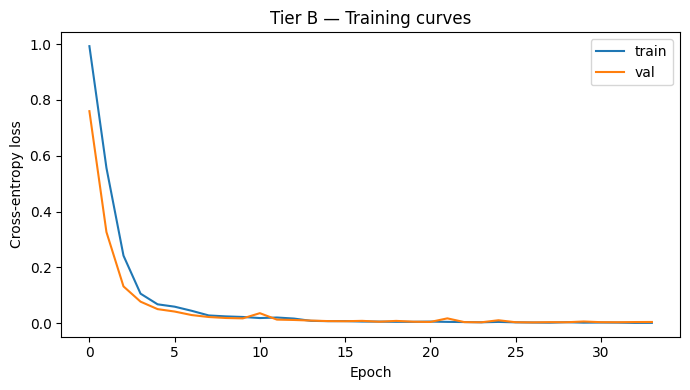

In [ ]:
# Train and val loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Tier B — Training curves')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tier_b_loss.png'), dpi=150)
plt.show()

=== Tier B (GloVe FF-NN) — Test ===
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        75
  Generic AI       1.00      1.00      1.00        75
    Mimic AI       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225

Accuracy: 1.0000
Macro-F1: 1.0000


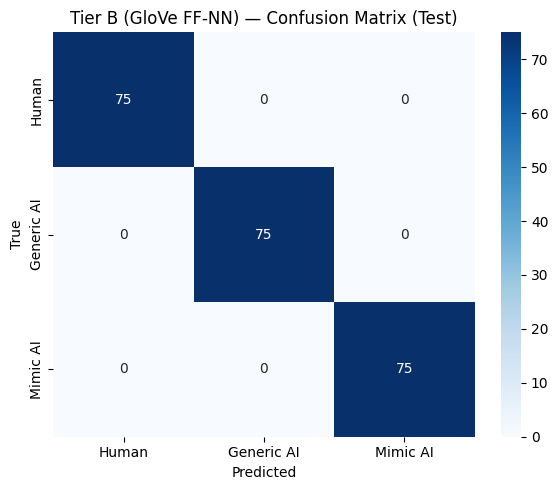

In [ ]:
# Evaluation function to get predictions and true labels from a dataloader 
def evaluate_model(model, loader, device):
    model.eval()
    preds, truths = [], [] 
    with torch.no_grad():
        for xb, yb in loader: # Batches of (embedding vectors, labels)
            xb = xb.to(device) 
            logits = model(xb) # Forward pass
            preds.extend(logits.argmax(dim=1).cpu().numpy()) # Getting the predicted class indices and moving them to CPU for numpy conversion
            truths.extend(yb.numpy()) # Getting the true labels and moving them to CPU for numpy conversion
    return np.array(truths), np.array(preds) 


y_true_b, y_pred_b = evaluate_model(model_b, test_loader, device)

print('=== Tier B (GloVe FF-NN) — Test ===')
print(classification_report(y_true_b, y_pred_b,
      target_names=['Human', 'Generic AI', 'Mimic AI']))
print(f'Accuracy: {accuracy_score(y_true_b, y_pred_b):.4f}') 
print(f'Macro-F1: {f1_score(y_true_b, y_pred_b, average="macro"):.4f}')

cm_b = confusion_matrix(y_true_b, y_pred_b)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Human', 'Generic AI', 'Mimic AI'],
            yticklabels=['Human', 'Generic AI', 'Mimic AI'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Tier B (GloVe FF-NN) — Confusion Matrix (Test)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tier_b_confusion.png'), dpi=150)
plt.show()

**Per-class OOV Rate**

After the shocking 100% accuracy of Tier B, I want to check if the OOV rate difference between the three classes is a potential reason for this blunder.

In [ ]:
class0_texts = [r['text'] for r in train_records if r['label'] == 0]
class1_texts = [r['text'] for r in train_records if r['label'] == 1]
class2_texts = [r['text'] for r in train_records if r['label'] == 2]

oov_rates = {}
for class_name, texts in [('Human', class0_texts), 
                            ('Generic AI', class1_texts), 
                            ('Mimic AI', class2_texts)]:
    total_words = 0
    oov_words = 0
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', text.lower())  # Using the same tokenization as embedding function
        total_words += len(words) 
        oov_words += sum(1 for w in words if w not in glove)
    oov_rates[class_name] = oov_words / total_words
    print(f"{class_name}: OOV rate = {oov_rates[class_name]:.3f}")

Human: OOV rate = 0.007
Generic AI: OOV rate = 0.000
Mimic AI: OOV rate = 0.001


### **Tier B - Results**

**100% Accuracy and a Macro-F1 score of 1.0 (A nightmare)**

My first thought after looking at the results was that data leaked. I triple-checked every piece of code that processes the data and found nothing. My first thought was that maybe the OOV rate across classes could have something to do with this. Even if it did come out to be very different across classes, I was not thinking of it being the only reason for perfect classification. Turns out the OOV rates across classes are not that different anyways.

I initially planned on just documenting this and moving on to Tier C. But then I consulted DeepSeek's reasoning LLM. [[10]](https://chat.deepseek.com) It suggested that maybe GLoVe embeddings are encoding style in a way that I did not expect.

After going through my hypothesis and previously cited blogs and articles, I have come up with some observations and a revised hypothesis:

My reasoning at the start of this Tier B was that since all classes cover the same 10 topics, semantic embeddings should not be able to distinguish them. The gap here is that I was thinking of semantics as "what the paragraph is about". But GloVe embeddings also encode which specific words were used. Victorian proses (Class 0) use "wretched", "melancholy", "sublime", etc. AI-generated texts use "navigate", "framework", "dynamics", etc. These word sets are quite different and must live in different regions of the 300d feature space. 

Averaging the word vectors of a Class 0 paragraph lands in the "Victorian neighbourhood", while averaging the AI classes lands in the "modern English neighbourhood". Even though the topics were same, there were completely different vocabularies in the human and AI classes. Therefore, I believe the neural network had an easy job. [[11]](https://www.kaggle.com/discussions/general/297606)

The training curve confirmed this because the train and val loss track each other from epoch 1 with little gap, both converging to near-zero by epoch 7-8. This means the model found a really easy, generalizable pattern. No overfitting.

I can also confirm that the per-class OOV analysis showed Human text has a 0.7% OOV rate v/s 0.0% for Generic AI and 0.1% for Mimic AI. This means Victorian character names and rare vocabulary do not appear in GloVe's training corpus. Therefore, these words were skipped during embedding and Class 0 emeddings were computed from slightly fewer words than the AI classes. This is just a minor tweak though. Even if all the OOV words were removed, the remaining in-vocabulary Victorian words still sit in a different embedding region from modern AI vocabulary. 

**Revised H2:** Averaged GloVe embeddings don't fail on this task because lexical and writing style come together. The vocabulary choice is the style signal in this dataset.

My naive model picked this up.

However, the limitation of Tier B is still real. The 100% result is due to the gap between Victorian proses and modern English LLM outputs. Tier C's transformer doesn't rely on this gap because it reads syntax and word patterns, so it will be a better detector in principle. 

### **References for Tier B**

For boilerplate code and general understanding of GloVe, I referred to the [original paper](https://nlp.stanford.edu/pubs/glove.pdf) and the official Stanford NLP project page. [Bohrium AI](https://www.bohrium.com/en) helped summarize the GLoVe architecture and pointed out important sections for me to skim through because it was not feasible to read the entire paper in detail given the time constraints.
As cited in-line, I used [DeepSeek](https://chat.deepseek.com) for understanding what a 100% accuracy and 1.0 macro-F1 score could mean. It gave me common interpretations and suggestions based on its training data because it didn't have my entire notebook context. I connected the dots and came up with the revised hypothesis on my own based on DeepSeek's insights and my previously cited resources. [[12]](https://www.bohrium.com/en)

For coding assistance, I used [Github Copilot Assistant](https://github.com/copilot) in my VS Code . It was handy for the Dataset and FFNet classes' code snippets and structural suggestions. However, since my Copilot's knowledge cutoff is October 2024, it often failed to provide accurate parameter suggestions for the latest versions of PyTorch, Sklearn, and XGBoost. I had to cross-reference with the official documentation and the other cited sources. [[13]](https://github.com/copilot)

All the citations (hyperlinked to their source) that I have made in above MD cells are listed here:

1. GloVe: Global Vectors for Word Representation.Pennington et al. EMNLP 2014. https://nlp.stanford.edu/pubs/glove.pdf

2. GloVe Embeddings. Stanford NLP. https://nlp.stanford.edu/projects/glove/

3. Mastering NLP with GloVe Embeddings: Word Similarity, Sentiment Analysis, and More. Medium (Muneeb). https://muneebsa.medium.com/mastering-nlp-with-glove-embeddings-word-similarity-sentiment-analysis-and-more-27f731988c48

4. GloVe Glossary. Zilliz. https://zilliz.com/glossary/glove

5. Deal with Out-of-Vocabulary Word with Gensim Pretrained GloVe. StackOverflow. https://stackoverflow.com/questions/65372032/deal-with-out-of-vocabulary-word-with-gensim-pretrained-glove

6. Deep Learning Basics Part 10: Feed Forward Neural Networks (FFNN). Medium (Sasirekhar A). https://medium.com/@sasirekharameshkumar/deep-learning-basics-part-10-feed-forward-neural-networks-ffnn-93a708f84a31

7. Understanding Dropout in Deep Neural Networks. Medium (Codex). https://medium.com/codex/understanding-dropout-in-deep-neural-networks-95e7d1b11c58

8. Demystifying the Adam Optimizer in Machine Learning. Medium (Weidagang). https://medium.com/@weidagang/demystifying-the-adam-optimizer-in-machine-learning-4401d162cb9e

9. Regularization for Neural Network. Halim Noor. https://halimnoor.com/regularization-for-neural-network/

10. DeepSeek conversation on Tier B results interpretation and revised hypothesis formulation. https://chat.deepseek.com

11. Discussion on GloVe embeddings encoding style. Kaggle. https://www.kaggle.com/discussions/general/297606

12. Bohrium AI - GLoVe Architecture Summary. https://www.bohrium.com/en

13. GitHub Copilot Assistant in VS Code. https://github.com/copilot

---

### **Tier C (The Transformer) - DistilBERT + LoRA**

**[EDIT]:** While writing this section, I forgot to add the citations along the way because everything was inter-connected and I was juggling between many resources for the theory and implementation. Forgive me for the citation bomb at the end of this cell.

<br>

[DistilBERT](https://arxiv.org/pdf/1910.01108) (Sanh et al., 2019) is a 40% smaller, 60% faster distilled version of BERT-base that retains ~97% of BERT's performance. I have chosen it over RoBERTa because it is a smaller model which makes it easier to train and inference in later tasks. Also, my paragraphs are short (150-200 words) which fall under DistilBERT's 512-token limit.

I will use [LoRA](https://arxiv.org/pdf/2106.09685) (Hu et al., 2021) over full fine-tuning, as instructed in the task. The idea is that the changes needed to adapt the pre-trained model to my specific task can be captured by a small number of parameters, i.e., instead of updating all ~66M parameters, I can insert small trainable rank-decomposition matrices into the attention layers. These matrices, when multiplied together, will approximate the necessary update. This way, I will need to **train only 12,288 parameters per matrix instead of 589,824.**

Each attention weight matrix W in DistilBERT has shape (768 x 768) because the **hidden dimension (d) is 768**. Full fine-tuning will modify  W directly, i.e., `768x768 = 589,824` parameters per matrix. Instead, LoRA will freeze W and will add a bypass. The effective weight will become `W + (A x B)`, where A has shape ( 768 x *r* ) and B has shape ( *r* x 768 ), with *r* being the rank ( *r* = 8 in LoRA config ). So instead of `768x768 = 589,824` parameters, LoRA will add `768x8 + 8x768 = 12,288` parameters per matrix. This is a **48x** reduction per matrix. 

**LoRA config:**
**`rank (r) = 8, lora_alpha = 16, lora_dropout = 0.1`**

The original LoRA paper found that **rank = 8** was sufficient for many NLP tasks, so I am starting with that. LoRA's only assumption is that the useful fine-tuning update lives in a low-dimensional subspace of the full weight space, so **rank = 8** will be enough to capture it. I will set **dropout = 0.1** because it is a common default for regularizing without being too aggressive. It basically means that during training, 10% of the LoRA updates will be randomly zeroed out. This will prevent the model from relying too much on any single update.

I will target the query and value projection matrices (`q_lin`, `v_lin` as named in DistilBERT) because they are the most critical components for attention mechanisms in terms of determining how tokens attend to each other.  The original LoRA paper found that adapting Q and V provides most of the fine-tuning benefit, while adding K and the feed-forward layers provides diminishing returns. Intuitively, adapting Q and V is enough to direct what the model pays attention to and what it extracts, without re-learning the matching criterion (Q, K, V) from scratch.

While fine-tuning, I have to ensure that the LoRA updates are applied at the right scale relative to the frozen pre-trained weights. The actual LoRA update applied is: `(lora_alpha / r) * A x B`, where **lora_alpha** is the **scaling factor**. If I set it too low, the LoRA update might be too small that the optimizer ignores it, but if I set it too high, the LoRA update might dominate the pre-trained weights and lead to loss of the pre-trained language knowledge (overfitting). The LoRA authors recommend setting `lora_alpha = 2*r` (16 = 2*8) as a standard default, which applies the updates at a moderate scale. 

Since BERT-family models are pre-trained with tuned weights, their pre-trained knowledge will be destroyed in the first few steps if I set the learning rate too high. This is called catastrophic forgetting. While going through a lot of articles about previous works related to fine-tuning DistilBERT and usage of LoRA, I found that the community-standard fine-tuning learning rate for BERT-family models is **2e-5**, validated across hundreds of downstream tasks. I will combine this with `warmup_steps=100` (the learning rate will ramp up from 0 to 2e-5 over the first 100 steps) to avoid a sharp gradient spike at the start of training, thus stabilizing the pre-trained weights. [[1]](https://arxiv.org/pdf/1910.01108) [[2]](https://arxiv.org/pdf/2106.09685) [[3]](https://medium.com/techsalo-infotech/parameter-efficient-fine-tuning-using-lora-da44151ecfee) [[4]](https://medium.com/@karkar.nizar/fine-tuning-bert-for-text-classification-with-lora-f12af7fa95e4) [[5]](https://arxiv.org/pdf/2503.07927) [[6]](https://medium.com/@mujahidabdullahi1992/an-introduction-to-lora-unpacking-the-theory-and-practical-implementation-e665c5d78295)  [[7]](https://medium.com/data-science/fine-tuning-large-language-models-llms-23473d763b91) [[8]](https://cobusgreyling.medium.com/catastrophic-forgetting-in-llms-bf345760e6e2)  [[9]](https://huggingface.co/docs/peft/developer_guides/checkpoint) 

In [8]:
# Autotokenizer will automatically choose the right tokenizer for the given 'distilbert-base-uncased' model

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType # Parameter-efficient fine-tuning (peft) library helps in fine-tuning LLMs with fewer trainable params
from datasets import Dataset as HFDataset
import evaluate

MODEL_NAME = 'distilbert-base-uncased' 
MAX_LEN    = 512
NUM_LABELS = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # 'distilbert-base-uncased' uses the same WordPiece tokenizer as BERT, but with a smaller vocabulary and fewer layers
print(f'Loaded tokenizer: {MODEL_NAME}')

Loaded tokenizer: distilbert-base-uncased


In [9]:
# Using HFDataset because it will fit well with the Hugging Face Trainer API that I will use later

def make_hf_dataset(records): # Using just the 'text' and 'label' fields from the records 
    return HFDataset.from_dict({
        'text':  [r['text']  for r in records],
        'label': [r['label'] for r in records],
    })

# Tokenizing the Hugging Face datasets in batches of samples
def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length', # Padding shorter texts to the max length (512 tokens) with special padding tokens because DistilBERT will expect fixed-length inputs
        truncation=True, # Truncating texts that exceed the max token length
        max_length=MAX_LEN, # DistilBERT's max input length is 512 tokens
    )

# Mapping the tokenization function over the datasets
hf_train = make_hf_dataset(train_records).map(tokenize_fn, batched=True)
hf_val   = make_hf_dataset(val_records).map(tokenize_fn, batched=True)
hf_test  = make_hf_dataset(test_records).map(tokenize_fn, batched=True)

# Checking truncation and max token lengths in the first 100 training samples
lens = [len(tokenizer.encode(r['text'])) for r in train_records[:100]]
print(f'Max token length in first 100 train samples: {max(lens)}')
print(f'Truncation triggered? {any(l > MAX_LEN for l in lens)}')

Map:   0%|          | 0/1049 [00:00<?, ? examples/s]

Map:   0%|          | 0/226 [00:00<?, ? examples/s]

Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Max token length in first 100 train samples: 317
Truncation triggered? False


In [ ]:
# AutoModelForSequenceClassification will load the pre-trained model and add a classification head on top of it for fine-tuning on our specific task

base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS, # Here, 3 (Human, Generic AI, Mimic AI)
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Sequence classification task
    r=8, # Rank of the low-rank adaptation matrices (discussed in the introductory cell above)
    lora_alpha=16, # Scaling factor for the LoRA updates
    lora_dropout=0.1, # Randomly zeroing out 10% of the LoRA updates during training for regularization
    target_modules=['q_lin', 'v_lin'],  # Freezing DistilBERT's Q and V projections
    bias='none', # I don't want to fine-tune the bias terms because they are not as important as the weight matrices and it will further reduce the number of trainable parameters
)

# Wrapping the base model with LoRA. I will only train the LoRA parameters and the rest of the model's parameters will be frozen
model_c = get_peft_model(base_model, lora_config) 
model_c.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


**Observation:** 

I can see that the above report shows that **740,355** parameters are trainable, which are the LoRA parameters that were addded to the frozen DistilBERT. This is a small fraction (1.09%) of the total 67M parameters, thus, I can confirm that LoRA is a parameter-efficient fine-tuning method. 

It is roughly in line with the expected **12,288** parameters per matrix for the two matrices (Q and V) across 6 layers: `12,288 x 2 x 6 = 147,456` parameters. The rest of the **592,899** trainable parameters come from the new classification head (pre_classifier and classifier) that I added on top of DistilBERT.

The UNEXPECTED keys are the original DistilBERT parameters that were loaded successfully (not trainable because they are frozen). The MISSING keys are the new classification head parameters that were randomly initialized, which is expected because DistilBERT was pre-trained for masked language modeling, not sequence classification. I will be training these parameters from scratch on my task. [[3]](https://medium.com/techsalo-infotech/parameter-efficient-fine-tuning-using-lora-da44151ecfee) [[4]](https://medium.com/@karkar.nizar/fine-tuning-bert-for-text-classification-with-lora-f12af7fa95e4) [[9]](https://huggingface.co/docs/peft/developer_guides/checkpoint)

In [ ]:
accuracy_metric = evaluate.load('accuracy') # HuggingFace's accuracy metric
# I will also use sklearn's f1_score function for computing the macro F1 score because the classes are imbalanced 

def compute_metrics(eval_pred):
    logits, labels = eval_pred # Tuple of (logits, labels) returned by the model 
    preds = np.argmax(logits, axis=-1) # Converting logits to predicted class indices by taking the argmax along the last dimension (class)
    acc = accuracy_metric.compute(predictions=preds, references=labels)['accuracy'] 
    f1  = f1_score(labels, preds, average='macro')
    return {'accuracy': acc, 'macro_f1': f1}

# Setting up the training arguments for the Hugging Face Trainer
# I am using a smaller batch size for training because of memory constraints but evaluation can be done with a larger batch size since it will not require backpropagation
training_args = TrainingArguments(
    output_dir=os.path.join(MODELS_DIR, 'distilbert_lora'), 
    num_train_epochs=5,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01, # Adding a small penalty to the loss function (L2 regularization) 
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50, 
    seed=42, # For reproducibility
    fp16=torch.cuda.is_available(),  # Mixed precision only for GPU (in case I switch to Colab). Will help speed up training
)

trainer = Trainer(
    model=model_c,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], # Early stopping if no improvement in macro-F1 for 2 consecutive evaluation epochs
)

trainer.train()

# [EDIT]: Please ignore the "Could not render content..." message because I restarted my IDE and lost the Tqdm progress bar. I will need to re-run this training loop to get the progress bars back, which doesn't make sense.

d:\Precog-Recruitment-Task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.097771,1.023341,0.955752,0.955207
2,1.001266,0.711102,1.000000,1.000000
3,0.772616,0.354087,1.000000,1.000000
4,0.296631,0.197712,1.000000,1.000000


d:\Precog-Recruitment-Task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Precog-Recruitment-Task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Precog-Recruitment-Task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=264, training_loss=0.7055623684868668, metrics={'train_runtime': 2284.1841, 'train_samples_per_second': 2.296, 'train_steps_per_second': 0.144, 'total_flos': 565386376126464.0, 'train_loss': 0.7055623684868668, 'epoch': 4.0})

In [ ]:
# First and foremost, saving the fine-tuned model and tokenizer to the models directory
SAVE_PATH = os.path.join(MODELS_DIR, 'distilbert_lora_final')
model_c.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model saved to {SAVE_PATH}')

Model saved to ../models\distilbert_lora_final


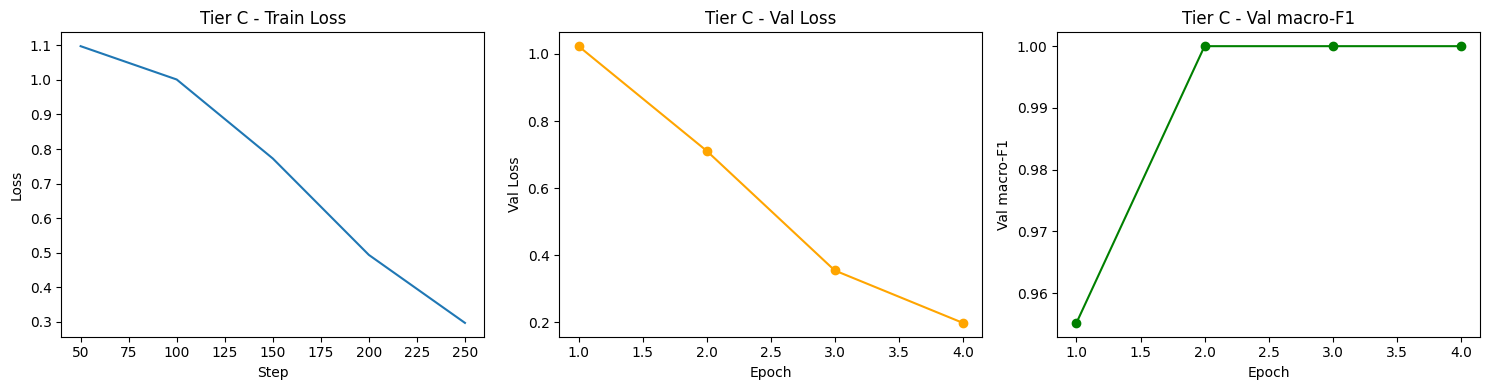

In [ ]:
# Extracting the training and evaluation logs from the trainer to plot the loss and macro-F1 curves. 

log_history = trainer.state.log_history # List of dictionaries containing the training and evaluation logs recorded at each logging step and evaluation epoch
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot([x['step'] for x in train_logs], [x['loss'] for x in train_logs])
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Tier C - Train Loss')

axes[1].plot([x['epoch'] for x in eval_logs], [x['eval_loss'] for x in eval_logs], 
             marker='o', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Tier C - Val Loss')

axes[2].plot([x['epoch'] for x in eval_logs], [x['eval_macro_f1'] for x in eval_logs], 
             marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val macro-F1')
axes[2].set_title('Tier C - Val macro-F1')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tier_c_curves.png'), dpi=150)
plt.show()

d:\Precog-Recruitment-Task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- Tier C Test ---
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        75
  Generic AI       1.00      1.00      1.00        75
    Mimic AI       1.00      1.00      1.00        75

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225

Accuracy: 1.0000
Macro-F1: 1.0000


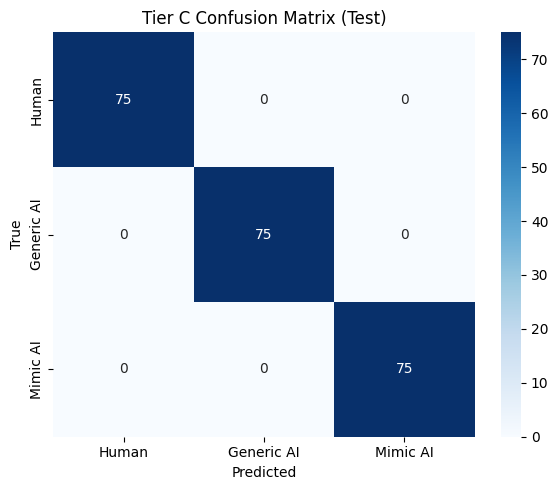

In [ ]:
# Evaluating the fine-tuned model on the test set
test_output = trainer.predict(hf_test)
y_pred_c = np.argmax(test_output.predictions, axis=-1) # Converting the logits to predicted class indices
y_true_c = np.array([r['label'] for r in test_records]) # Extracting the true labels

print('--- Tier C Test ---')
print(classification_report(y_true_c, y_pred_c,
      target_names=['Human', 'Generic AI', 'Mimic AI']))
print(f'Accuracy: {accuracy_score(y_true_c, y_pred_c):.4f}')
print(f'Macro-F1: {f1_score(y_true_c, y_pred_c, average="macro"):.4f}')

cm_c = confusion_matrix(y_true_c, y_pred_c)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Human', 'Generic AI', 'Mimic AI'],
            yticklabels=['Human', 'Generic AI', 'Mimic AI'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Tier C Confusion Matrix (Test)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tier_c_confusion.png'), dpi=150)
plt.show()

### **Tier C - Results and Observations**

**100% Accuracy and a Macro-F1 score of 1.0 on the test set.** Such perfect results for this dataset are not a surprise for me anymore because my eyes have seen enough in Tier A and B.
Early stopping triggered at epoch 4 because val macro-F1 plateaued at 1.0 from epoch 2 onwards. 

**This is not overfitting** because Val loss decreased every epoch (1.023 -> 0.711 -> 0.354 -> 0.197). Overfitting would have shown val loss increasing while train loss decreasing continuously. I can see in the train loss curve that the learning was stable (from 1.1 to 0.3 over 4 epochs) with no spike. I can confirm that the model found a clean decision boundary by epoch 2 and the remaining epochs refined internal representations without changing the predictions.

I can say that **H3 has been confirmed** in the sense that Tier C performed at least as well as Tiers A and B. Well, it did not outperform them because there was no room since all three tiers reached the ceiling performance. However, the more meaningful question would be what each tier detected rather than checking which tier did the best job. 

Tier A detected stylometric signatures (past tense, semicolons, commas) and Tier B detected lexical choice (Victorian vs modern AI vocabulary). Tier C, a transformer model, read subword patterns, attention distributions, and contextual relationships that are not expressible merely as 15 numbers.

I have saved the model to `../models/distilbert_lora_final` and will use it in Task 3 to interpret what Tier C learned, and in Task 4 for the genetic algorithm fitness function.

An interesting thing to note is that LoRA only updated 1.09% of the parameters, and yet it was enough to achieve 100% accuracy on a domain shift from general English Victorian proses. This means that DistilBERT's pre-trained representations already had features relevant to this task. Hence, LoRA just redirected them towards my classification boundary.

**Conclusion**

The finding of all the mess I created is that three very different architectures (a gradient-boosted tree, a feedforward neural network on averaged embeddings, and a fine-tuned transformer), all reached near-perfect accuracy. This means the stylometric gap between human-written Victorian proses and AI-generated texts is not subtle. Any model or approach that will look carefully at language patterns will be able to find it.

I began the task with an intention to "catch the ghost", but turns out my ghost was just standing with a flashing neon sign. :)

### **References for Tier C:**

To go through the most-relevant sections of the [DistilBERT](https://arxiv.org/abs/1910.01108) and [LoRA](https://arxiv.org/abs/2106.09685) papers, I used [Bohrium AI](https://www.bohrium.com/en). It helped me figure out which portions of the papers to read in detail and which ones to skim. Reading the paper helped me with my LoRA config choices (rank = 8, lora_alpha = 16, targeting Q and V matrices), which I cross-verified with HuggingFace PEFT documentation and previous works documented as Medium articles (cited). [[10]](https://www.bohrium.com/en)

I used [Github Copilot](https://github.com/copilot) in my VS Code IDE for coding assistance while implementing the fine-tuning. It was helpful for forming a general structure, which I had to verify from previous works on Medium and HuggingFace (cited). However, Copilot constantly gave outdated suggestions for the latest versions of some libraries. For example, it suggested `tokenizing_class` instead of `processing_class` in the HuggingFace Trainer, which is a recent change. I had to go through the documentation to figure out the correct parameters. I also used it to generate the training loop structure, and verified it against the HuggingFace Trainer documentation and published notebooks (cited). [[11]](https://github.com/copilot)

All the citations (hyperlinked to their source) that I have made in above MD cells are listed here:

1. DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. ArXiv (Sanh et al., 2019). https://arxiv.org/pdf/1910.01108

2. LoRA: Low-Rank Adaptation of Large Language Models. ArXiv (Hu et al., 2021). https://arxiv.org/pdf/2106.09685

3. Parameter Efficient Fine-Tuning using LoRA. Medium (Techsalo Infotech). https://medium.com/techsalo-infotech/parameter-efficient-fine-tuning-using-lora-da44151ecfee

4. Fine-tuning BERT for Text Classification with LoRA. Medium (Karkar Nizar). https://medium.com/@karkar.nizar/fine-tuning-bert-for-text-classification-with-lora-f12af7fa95e4

5. A Study to Evaluate the Impact of LoRA Fine-tuning on the Performance of Non-functional Requirements Classification. Arxiv (Li et. al., 2025). https://arxiv.org/pdf/2503.07927

6. An Introduction to LoRA: Unpacking the Theory and Practical Implementation. Medium (Mujahid Abdullahi). https://medium.com/@mujahidabdullahi1992/an-introduction-to-lora-unpacking-the-theory-and-practical-implementation-e665c5d78295

7. Fine-tuning Large Language Models (LLMs). Medium (Data Science). https://medium.com/data-science/fine-tuning-large-language-models-llms-23473d763b91

8. Catastrophic Forgetting in LLMs. Medium (Cobus Greyling). https://cobusgreyling.medium.com/catastrophic-forgetting-in-llms-bf345760e6e2

9. HuggingFace PEFT Checkpointing. https://huggingface.co/docs/peft/developer_guides/checkpoint

10. Bohrium AI. https://www.bohrium.com/en

11. Github Copilot assistant in VS Code. Github. https://github.com/copilot